# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.


1. Clean the data and perform some EDA and visualization to get to know the data set.


   Body_Type  Average Price
0  crossover   7.050952e+05
1  hatchback   5.339773e+05
2        muv   6.264211e+05
3      sedan   8.097841e+05
4        suv   1.176495e+06


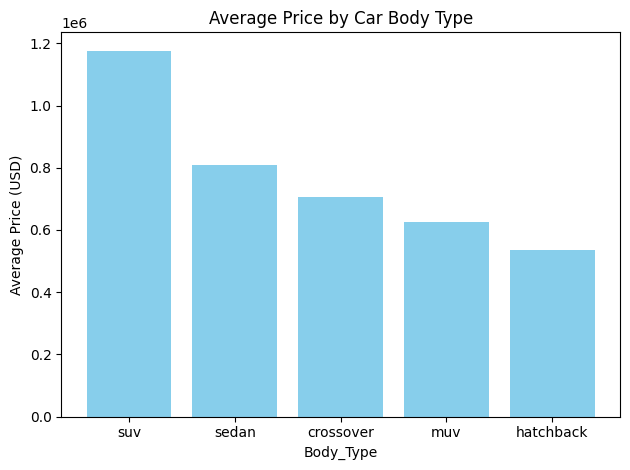

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv( "/workspace/labs/04_hedonic_pricing/cars_hw.csv" )

df = df.dropna()

# clean the "number of owners" variable to integer by removing letters
df['No_of_Owners'] = df['No_of_Owners'].str.replace(r'\D', '', regex=True)

# Group by 'Model' and calculate the average price
average_prices_by_model = df.groupby('Body_Type')['Price'].mean().reset_index()

# Rename the columns for clarity
average_prices_by_model.columns = ['Body_Type', 'Average Price']

# Display the result
print(average_prices_by_model)

# Sort by average price for better visualization
average_prices_by_model = average_prices_by_model.sort_values(by='Average Price', ascending=False)

# Plotting the average prices by model
plt.bar(average_prices_by_model['Body_Type'], average_prices_by_model['Average Price'], color='skyblue')

# Adding labels and title
plt.xlabel('Body_Type')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Car Body Type')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

# from the bar graph, we see that SUVs have the highest average price and hatchbacks have the lowest.

             Make  Average Price
0       Chevrolet   4.535000e+05
1          Datsun   2.896667e+05
2            Ford   7.211731e+05
3           Honda   7.989726e+05
4         Hyundai   6.918918e+05
5            Jeep   1.499500e+06
6             Kia   1.614750e+06
7       MG Motors   1.869457e+06
8        Mahindra   1.100167e+06
9   Maruti Suzuki   5.887850e+05
10         Nissan   8.842500e+05
11        Renault   6.625735e+05
12          Skoda   1.136000e+06
13           Tata   1.055217e+06
14         Toyota   8.003400e+05
15     Volkswagen   6.058276e+05


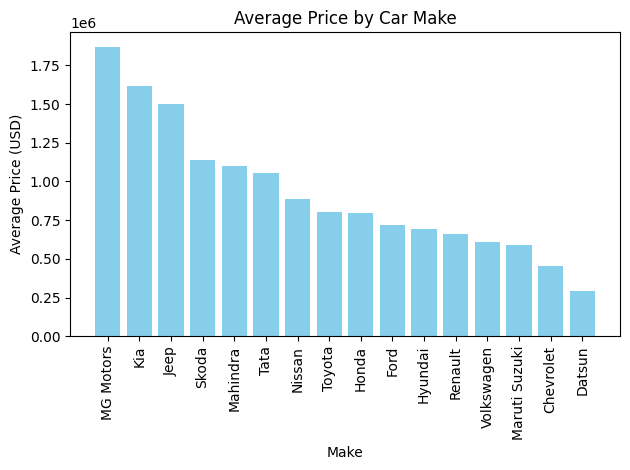

In [4]:
# price by car make

# Group by 'Model' and calculate the average price
average_prices_by_make = df.groupby('Make')['Price'].mean().reset_index()

# Rename the columns for clarity
average_prices_by_make.columns = ['Make', 'Average Price']

# Display the result
print(average_prices_by_make)

# Sort by average price for better visualization
average_prices_by_make = average_prices_by_make.sort_values(by='Average Price', ascending=False)

# Plotting the average prices by model
plt.bar(average_prices_by_make['Make'], average_prices_by_make['Average Price'], color='skyblue')

# Adding labels and title
plt.xlabel('Make')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Car Make')
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

# MG Motors and Kia have the highest average car price, whereas Chevy and Datsun have the lowest.

<Axes: xlabel='Make_Year', ylabel='Price'>

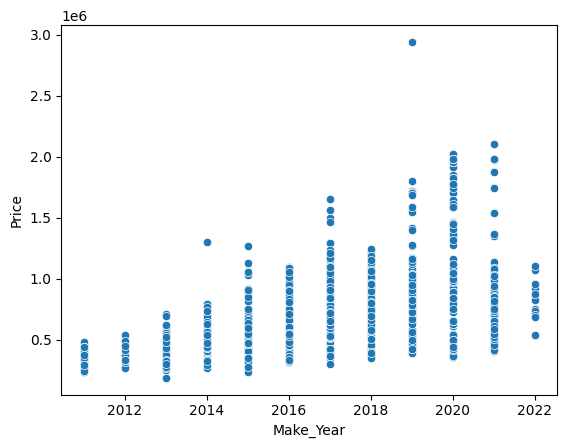

In [5]:
df_transformed = df

# see if there are any outliers when relating price and year of make:
sns.scatterplot(data=df_transformed,y='Price',x='Make_Year')
# there seem to be relatively few outliers -- might not need a transformation

<Axes: xlabel='make_year_ihs', ylabel='price_ihs'>

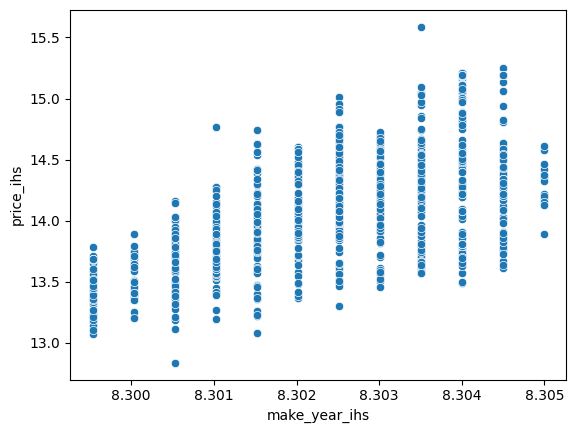

In [6]:
df_transformed['price_ihs'] = np.arcsinh(df_transformed['Price'])
df_transformed['make_year_ihs'] = np.arcsinh(df_transformed['Make_Year'])
sns.scatterplot(data=df_transformed,y='price_ihs',x='make_year_ihs') 
# after transforming the data using arcsinh, we see a little bit of improvement for that top outlier

<Axes: >

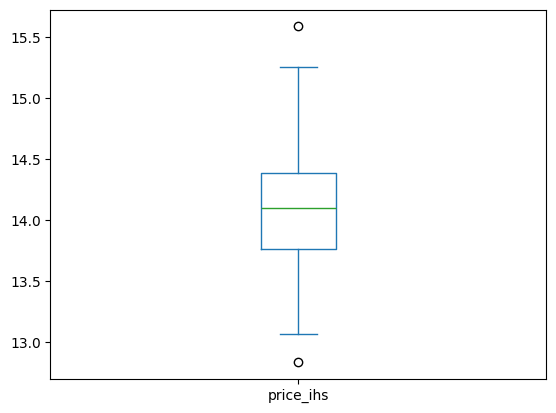

In [7]:
df_transformed['price_ihs'].plot.box()
# price distribution is normal just two outliers. We can remove these:


<Axes: >

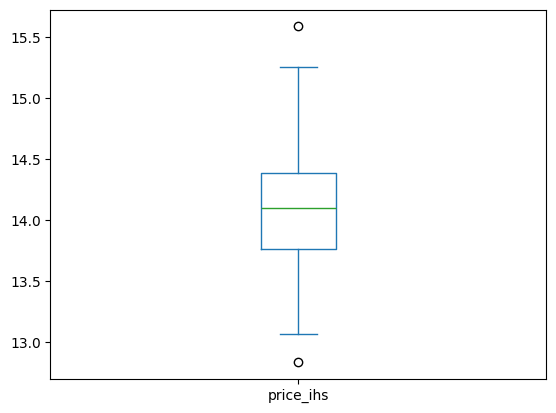

In [8]:

df_transformed['price_ihs'].plot.box()
# outliers removed

<Axes: >

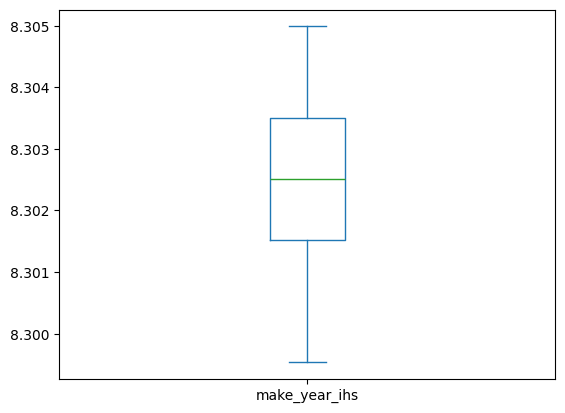

In [9]:
df_transformed['make_year_ihs'].plot.box()

2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.

In [10]:
# I did this in step 4 instead

3. Implement an ~80/~20 train-test split. Put the test data aside.


In [11]:
# code modified from https://sparkbyexamples.com/pandas/pandas-create-test-and-train-samples-from-dataframe/ 

from sklearn.model_selection import train_test_split
X = df.drop(columns='Price')
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=100)


4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

In [12]:

# code adapted using chat gpt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Separate features (X) and target variable (y)
X = df_transformed.drop(columns='Price')  # Replace with your target column name
y = df_transformed['Price']

# Convert categorical variables to numerical using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)
for col in X_encoded.columns:
    print(col)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the linear regression model
model = LinearRegression()

# Fit the model on the training set
model.fit(X_train, y_train)

# Make predictions on the training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate RMSE for training and test sets
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Calculate R^2 for training and test sets
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Output the results
print(f"Training RMSE: {rmse_train}")
print(f"Test RMSE: {rmse_test}")
print(f"Training R^2: {r2_train}")
print(f"Test R^2: {r2_test}")

# R^2 is very high at .96


Unnamed: 0
Make_Year
Mileage_Run
Seating_Capacity
price_ihs
make_year_ihs
Make_Datsun
Make_Ford
Make_Honda
Make_Hyundai
Make_Jeep
Make_Kia
Make_MG Motors
Make_Mahindra
Make_Maruti Suzuki
Make_Nissan
Make_Renault
Make_Skoda
Make_Tata
Make_Toyota
Make_Volkswagen
Color_black
Color_blue
Color_bronze
Color_brown
Color_golden
Color_green
Color_grey
Color_maroon
Color_orange
Color_purple
Color_red
Color_silver
Color_white
Color_yellow
Body_Type_hatchback
Body_Type_muv
Body_Type_sedan
Body_Type_suv
No_of_Owners_2
No_of_Owners_3
Fuel_Type_petrol
Fuel_Type_petrol+cng
Transmission_5-Speed
Transmission_6-Speed
Transmission_7-Speed
Transmission_CVT
Transmission_Type_Manual
Training RMSE: 66157.94021023846
Test RMSE: 65231.693907133296
Training R^2: 0.968642682797239
Test R^2: 0.9629002486054643


5. Include transformations and interactions, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?


In [13]:
from sklearn.preprocessing import PolynomialFeatures

X = X_encoded

expander = PolynomialFeatures(degree=2,include_bias=False) # Create the expander
Z = expander.fit_transform(X) # Pass the df into the expander to get powers/interactions of x and y
names = expander.get_feature_names_out() # Get the names of these variables
zdf = pd.DataFrame(data=Z, columns = names) # Create a new, expanded dataframe
zdf.head()

,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,price_ihs,make_year_ihs,Make_Datsun,Make_Ford,Make_Honda,Make_Hyundai,...,Transmission_6-Speed^2,Transmission_6-Speed Transmission_7-Speed,Transmission_6-Speed Transmission_CVT,Transmission_6-Speed Transmission_Type_Manual,Transmission_7-Speed^2,Transmission_7-Speed Transmission_CVT,Transmission_7-Speed Transmission_Type_Manual,Transmission_CVT^2,Transmission_CVT Transmission_Type_Manual,Transmission_Type_Manual^2
0,1.0,2017.0,44611.0,5.0,14.088586,8.302514,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,2016.0,20305.0,5.0,14.125932,8.302018,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3.0,2019.0,29540.0,5.0,14.276726,8.303505,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.0,2017.0,35680.0,5.0,13.626768,8.302514,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5.0,2017.0,25126.0,5.0,13.845069,8.302514,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
## Compute all polynomials up to degree 3:
expander = PolynomialFeatures(degree=3,include_bias=False) # Create the expander
Z = expander.fit_transform(X) # Pass the df into the expander to get powers/interactions of x and y
names = expander.get_feature_names_out() # Get the names of these variables
zdf = pd.DataFrame(data=Z, columns = names) # Create a new, expanded dataframe
zdf.head()


,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,price_ihs,make_year_ihs,Make_Datsun,Make_Ford,Make_Honda,Make_Hyundai,...,Transmission_7-Speed^3,Transmission_7-Speed^2 Transmission_CVT,Transmission_7-Speed^2 Transmission_Type_Manual,Transmission_7-Speed Transmission_CVT^2,Transmission_7-Speed Transmission_CVT Transmission_Type_Manual,Transmission_7-Speed Transmission_Type_Manual^2,Transmission_CVT^3,Transmission_CVT^2 Transmission_Type_Manual,Transmission_CVT Transmission_Type_Manual^2,Transmission_Type_Manual^3
0,1.0,2017.0,44611.0,5.0,14.088586,8.302514,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,2016.0,20305.0,5.0,14.125932,8.302018,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3.0,2019.0,29540.0,5.0,14.276726,8.303505,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.0,2017.0,35680.0,5.0,13.626768,8.302514,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5.0,2017.0,25126.0,5.0,13.845069,8.302514,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [15]:

column_names = zdf.columns.tolist()
print(column_names)
# the dataframe contains interactions and powers for all of the trasnformed variables.

['Unnamed: 0', 'Make_Year', 'Mileage_Run', 'Seating_Capacity', 'price_ihs', 'make_year_ihs', 'Make_Datsun', 'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen', 'Color_black', 'Color_blue', 'Color_bronze', 'Color_brown', 'Color_golden', 'Color_green', 'Color_grey', 'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red', 'Color_silver', 'Color_white', 'Color_yellow', 'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan', 'Body_Type_suv', 'No_of_Owners_2', 'No_of_Owners_3', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng', 'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed', 'Transmission_CVT', 'Transmission_Type_Manual', 'Unnamed: 0^2', 'Unnamed: 0 Make_Year', 'Unnamed: 0 Mileage_Run', 'Unnamed: 0 Seating_Capacity', 'Unnamed: 0 price_ihs', 'Unnamed: 0 make_year_ihs', 'Unnamed: 0 Make_Datsun', 'Unnamed: 0

In [16]:
# create predictive model using interaction terms:

# X1 = Body_Type_suv
# X2 = Mileage_Run * Make_Year
# X3 = Mileage_Run
# X4 = Make_Year ^ 2
# X5 = Seating_Capacity

# code generated using help from chat gpt:

# Define predictors and response variable
X = zdf[['Body_Type_suv', 'Make_Year Mileage_Run', 'Mileage_Run', "Make_Year^2"]]
y = df['Price']

# Create interaction terms
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=0)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_squared = r2_score(y_test, y_pred)
print("R^2:", r_squared)

print("Root Mean Squared Error:", rmse)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# R^2 shrank to .53 (compared to .96 value when I used all of the variables in the dataset with no interactions).
# only a moderate amount of variation in the y variable is explained by the variables/interactions I chose

R^2: 0.5378864307635012
Root Mean Squared Error: 239611.76183885714
Coefficients: [-6.78448777e-02  1.48577531e+02  2.23054608e-01  1.10383248e+01
  1.11439422e+00 -2.24934693e+03  1.26855459e-01 -9.21069843e-09
  3.66503261e-05 -1.47585525e-01]
Intercept: -44370041.31767214


/tmp/ipykernel_730/3542421046.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', color='red', label='Ideal Fit')


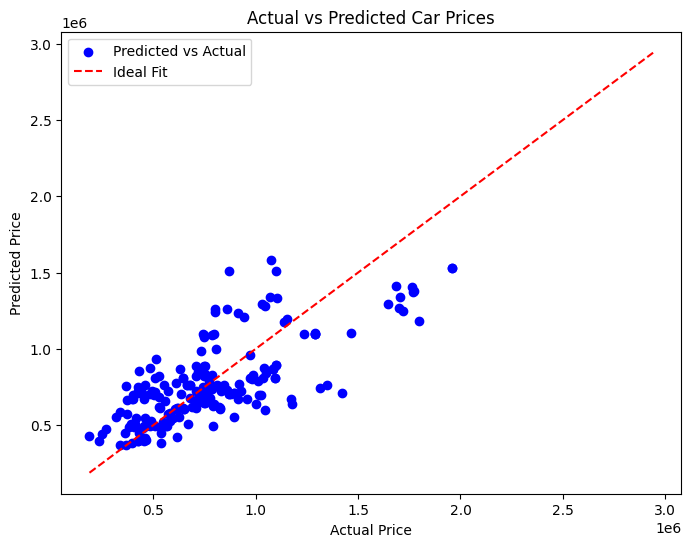

In [17]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', color='red', label='Ideal Fit')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.legend()
plt.show()

6. Summarize your results from 1 to 5. Have you learned anything about overfitting and underfitting, or model selection?


In [18]:
# 1. There are many factors influencing price, such as make, model, and year of production.

# 2. When dealing with categorical variables such as car model, which includes many possible values (such as ford, jeep, etc),
# using onehotcoder can get messy

# 3. N/A

# 4. Just because R^2 value is high (it was .96 in step 4) doesn't mean the model is a great predictor. The model still had a massive RMSE,
# suggesting some design flaws

# 5. Interactions must be included in the model only if economic/scientific intutiton tells you that they belong.


7. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.